In [2]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import cariaco_npzd_setups as cns          # NPZD model (replaces cariaco_baseline_setups)
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cns, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cns.phyto_esd, cns.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')
print(f'spec: K_sZ={cns.K_SZ}  σ={cns.SIGMA}  GGE={cns.GGE_VAL}  '
      f'm_Z={cns.M_Z}  m_Zlin={cns.M_ZLIN}  θ_opt={cns.THETA_OPT}  '
      f'fish_rate(default)={cns.FISH_RATE}')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)
spec: K_sZ=0.23  σ=0.15  GGE=0.25  m_Z=0.1  m_Zlin=0.05  θ_opt=10.0  fish_rate(default)=0.0


In [8]:
import baseline_r0_comps

In [11]:
import baseline_r0_setups as brs

In [13]:
outptu = pu.run_single_point(brs.model_baseline, brs.setup_baseline, scan_params={}, fixed_overrides={})

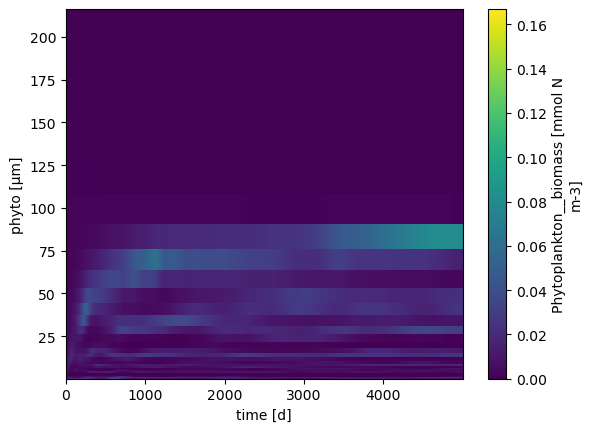

In [20]:
outptu.Phytoplankton__biomass.plot()


In [21]:
import baseline_r0_setups as brs
import parscan_utils as pu
import parscan_utils_extended as pue
import cariaco_obs as co

# obs side
_, _, _, monthly_df, forcing = co.load_cariaco_targets(regime='upwelling',
                                                       months='hplc', agg='median',
                                                       include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

# model side — single point at default forcing
out = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                          scan_params={}, fixed_overrides=forcing)
print(out)  # full output, should have Growth__uptake_value + DetritusSink__sinking_value

<xarray.Dataset> Size: 146MB
Dimensions:                                 (time: 5000, phyto: 40, zoo: 40,
                                             full: 80, clock: 2)
Coordinates:
  * time                                    (time) float64 40kB 0.0 ... 4.999...
  * phyto                                   (phyto) float64 320B 0.2 ... 200.0
  * zoo                                     (zoo) float64 320B 2.0 ... 2e+03
  * clock                                   (clock) float64 16B 0.0 1.0
Dimensions without coordinates: full
Data variables: (12/104)
    Core__solver_kwargs                     <U49 196B '{"method": "RK45", "at...
    Core__solver_type                       <U9 36B 'solve_ivp'
    DetritusRemin__detritus                 <U1 4B 'D'
    DetritusRemin__k_remin                  float64 8B 0.1
    DetritusRemin__nutrient                 <U1 4B 'N'
    DetritusRemin__remineralization_value   (time) float64 40kB 0.0002363 ......
    ...                                      ...
 

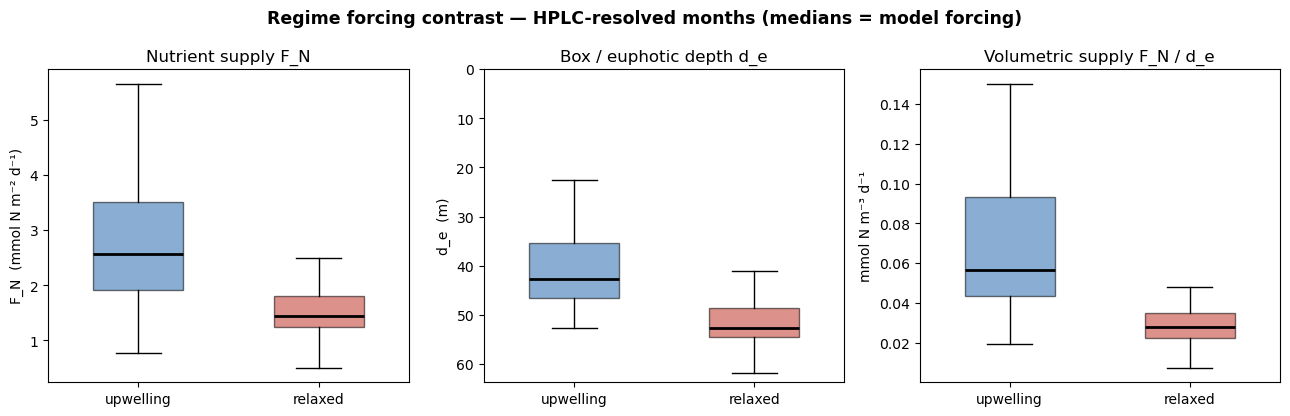

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [22]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

upwelling   CV(ΣP)=0.020   mcs model/obs = 5.20 / 4.84 µm
            model  Pico (<2 µm)=0.46  Nano (2-20 µm)=0.16  Micro (>20 µm)=0.38
            obs    Pico (<2 µm)=0.45  Nano (2-20 µm)=0.22  Micro (>20 µm)=0.31
            ΣZ gt200 model=0.014 / obs=0.083 mmolN m⁻³  (m/o=0.17)
            ΣZ gt500 model=0.003 / obs=0.051 mmolN m⁻³  (m/o=0.05)
relaxed     CV(ΣP)=0.008   mcs model/obs = 2.95 / 2.01 µm
            model  Pico (<2 µm)=0.54  Nano (2-20 µm)=0.24  Micro (>20 µm)=0.22
            obs    Pico (<2 µm)=0.61  Nano (2-20 µm)=0.26  Micro (>20 µm)=0.10
            ΣZ gt200 model=0.003 / obs=0.048 mmolN m⁻³  (m/o=0.06)
            ΣZ gt500 model=0.000 / obs=0.023 mmolN m⁻³  (m/o=0.00)


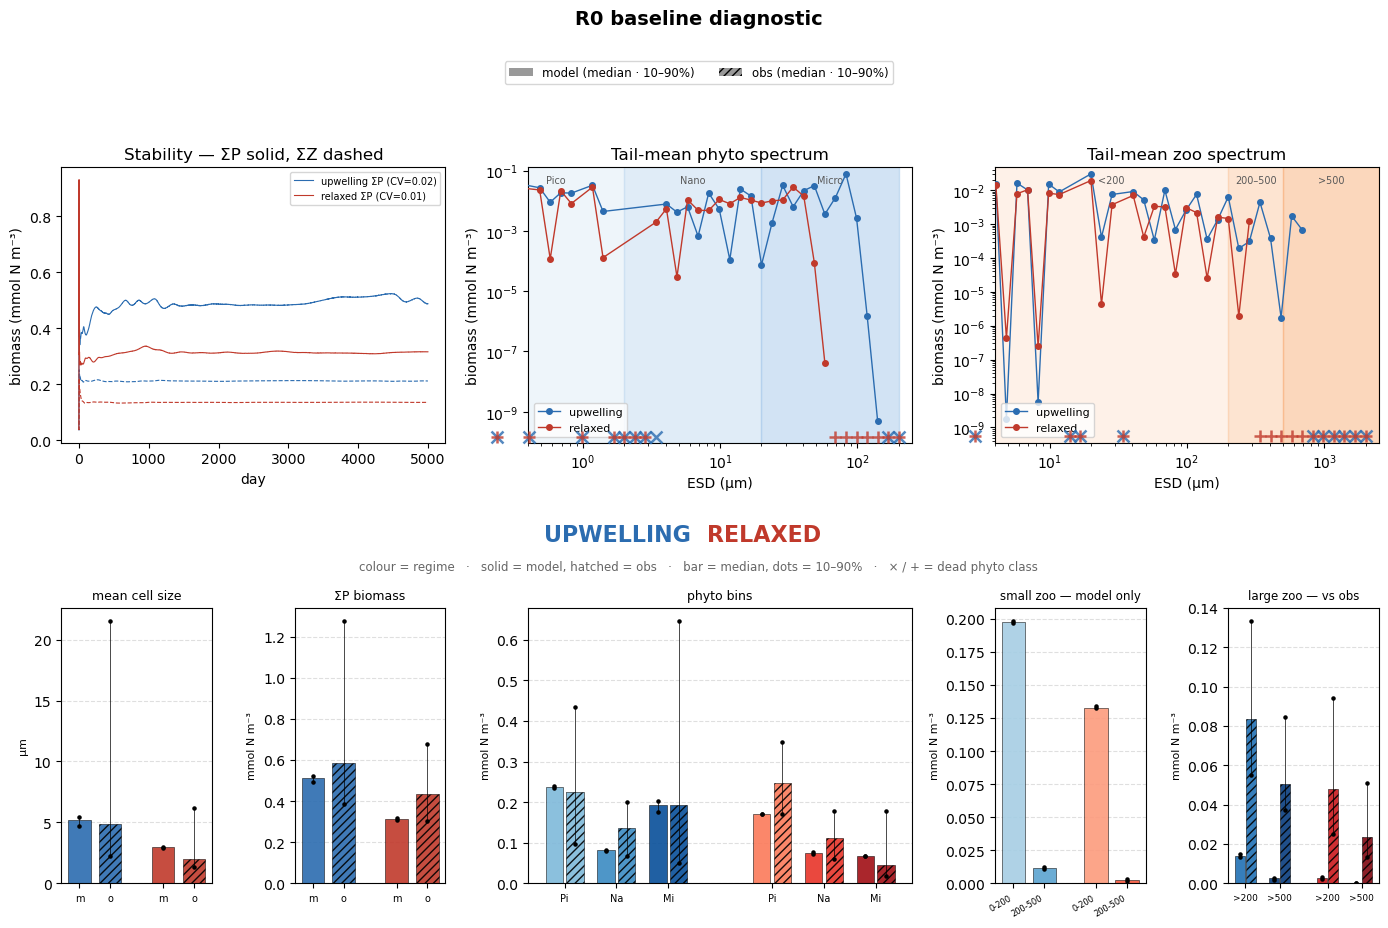

In [24]:
# ── Cell 5 (baseline_r0) — IVP per regime → tail-mean diagnostic vs obs ──────
# New construct: Taniguchi growth + uniform m_P = 0.02 (default in setup_baseline)
# + Dutkiewicz Type III (scalar K_sZ = 0.23) + Mattern σ = 0.15 kernel built at
# setup time via setup_func='_build_phiPZ'.
TAIL = 1000

def _bin_frac_model(proc):
    pb = np.asarray(proc['phyto_bins_tail'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), proc['phyto_bin_labels']

def _bin_frac_obs(obs):
    pb = np.vstack(obs['phyto_bins'])
    fr = pb / np.clip(pb.sum(axis=0, keepdims=True), 1e-12, None)
    return np.nanmedian(fr, axis=1), obs['phyto_bin_labels']

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                              scan_params={},
                              fixed_overrides=targets[r]['forcing'])
    model_by_regime[r] = pu.process_regime_run(out, brs.phyto_esd, brs.zoo_esd,
                                                bin_defs, tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    m_mcs = np.nanmedian(model_by_regime[r]['mcs_tail'])
    o_mcs = np.nanmedian(obs_by_regime[r]['mcs'])
    mfr, mlab = _bin_frac_model(model_by_regime[r])
    ofr, olab = _bin_frac_obs(obs_by_regime[r])
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.3f}   "
          f"mcs model/obs = {m_mcs:.2f} / {o_mcs:.2f} µm")
    print("            model  " + "  ".join(f"{l}={v:.2f}" for l, v in zip(mlab, mfr)))
    print("            obs    " + "  ".join(f"{l}={v:.2f}" for l, v in zip(olab, ofr)))
    # ── Large-Z diagnostic — Z>200µm and Z>500µm (the two data-constrained bands)
    # Caveat: obs zoo bongo-tows integrate 0–200 m, NOT the model's euphotic box;
    # absolute m/o ratios carry a known depth-mismatch systematic — read shapes, not levels.
    for thr_key, obs_label in [('gt200', 'Zoo >200 µm'), ('gt500', 'Zoo >500 µm')]:
        mZ = np.nanmedian(model_by_regime[r]['zoo_cum_tail'][thr_key])
        oZv = obs_by_regime[r]['zoo'].get(obs_label, np.array([]))
        oZ = np.nanmedian(oZv) if len(oZv) else np.nan
        ratio = mZ / oZ if (np.isfinite(oZ) and oZ > 0) else np.nan
        print(f"            ΣZ {thr_key:5s} model={mZ:.3f} / obs={oZ:.3f} mmolN m⁻³  (m/o={ratio:.2f})")

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                brs.phyto_esd, brs.zoo_esd, regimes=regimes)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 45.71531 seconds.

=== K_sZ — UPWELLING  (F_N=2.58, d_e=42.8) ===
  K_sZ    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   4.75   0.147   0.028   0.112   0.286  0.0294  0.0105   0.162   0.199   0.505   0.143   2.523
 0.115   5.20   0.158   0.032   0.131   0.321  0.0265  0.0086   0.169   0.171   0.504   0.142   2.518
 0.129   5.76   0.168   0.036   0.154   0.357  0.0231  0.0081   0.177   0.151   0.502   0.142   2.512
 0.144   5.63   0.179   0.042   0.160   0.380  0.0218  0.0047   0.183   0.134   0.501   0.142   2.507
 0.158   5.73   0.189   0.046   0.172   0.407  0.0207  0.0047   0.

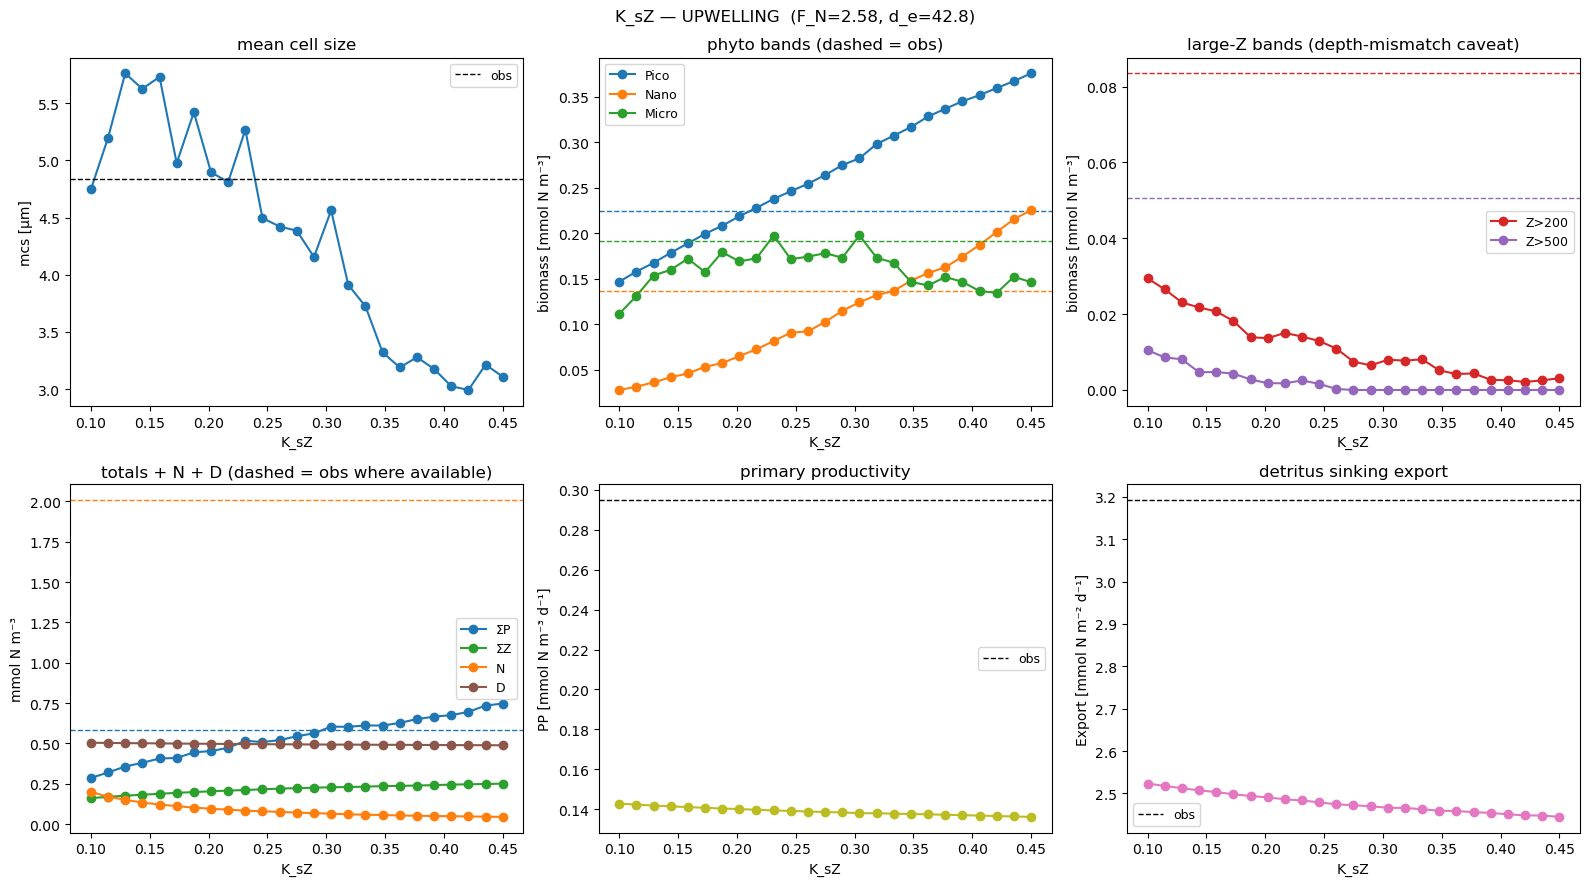

In [27]:
# ── Cell — K_sZ sweep, UPWELLING ────────────────────────────────────────────
# Grazing__KsZ is now a SCALAR parscan axis after the baseline_r0 refactor.
# Range: 0.10 → 0.45, 8 points linear. Covers the Type III literature window
# (Ward 2012 / Dutkiewicz 2020 / Rohr 2022, per Size Spectral Survey §8);
# 0.10 captures the low end. Skip ≤0.05 (prior NaN region).
from xso.parscans import run_xso_parscan

PARAM       = 'Grazing__KsZ'
AXIS_LABEL  = 'K_sZ'
AXIS_VALUES = np.linspace(0.10, 0.45, 25)   # baseline 0.23 inside this range
REGIME      = 'upwelling'
TAIL_AVG    = 1000

obs_refs_up = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_KsZ_up = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_KsZ_up = pue.extract_scan_metrics_1d(
    scan_KsZ_up, PARAM, targets[REGIME]['forcing'])

header_up = (f"K_sZ — {REGIME.upper()}  "
             f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
             f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_KsZ_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_KsZ_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 25 points using 8 workers...
1D Scan complete. Time taken: 43.53984 seconds.

=== K_sZ — RELAXED  (F_N=1.45, d_e=52.7) ===
  K_sZ    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   3.99   0.103   0.021   0.066   0.190  0.0096  0.0017   0.103   0.093   0.284   0.072   1.422
 0.115   4.18   0.111   0.026   0.073   0.211  0.0082  0.0009   0.109   0.083   0.284   0.072   1.419
 0.129   4.06   0.120   0.031   0.076   0.226  0.0071  0.0011   0.113   0.074   0.283   0.071   1.416
 0.144   3.84   0.127   0.037   0.076   0.241  0.0068  0.0002   0.117   0.068   0.283   0.071   1.414
 0.158   3.46   0.135   0.042   0.071   0.248  0.0051  0.0000   0.12

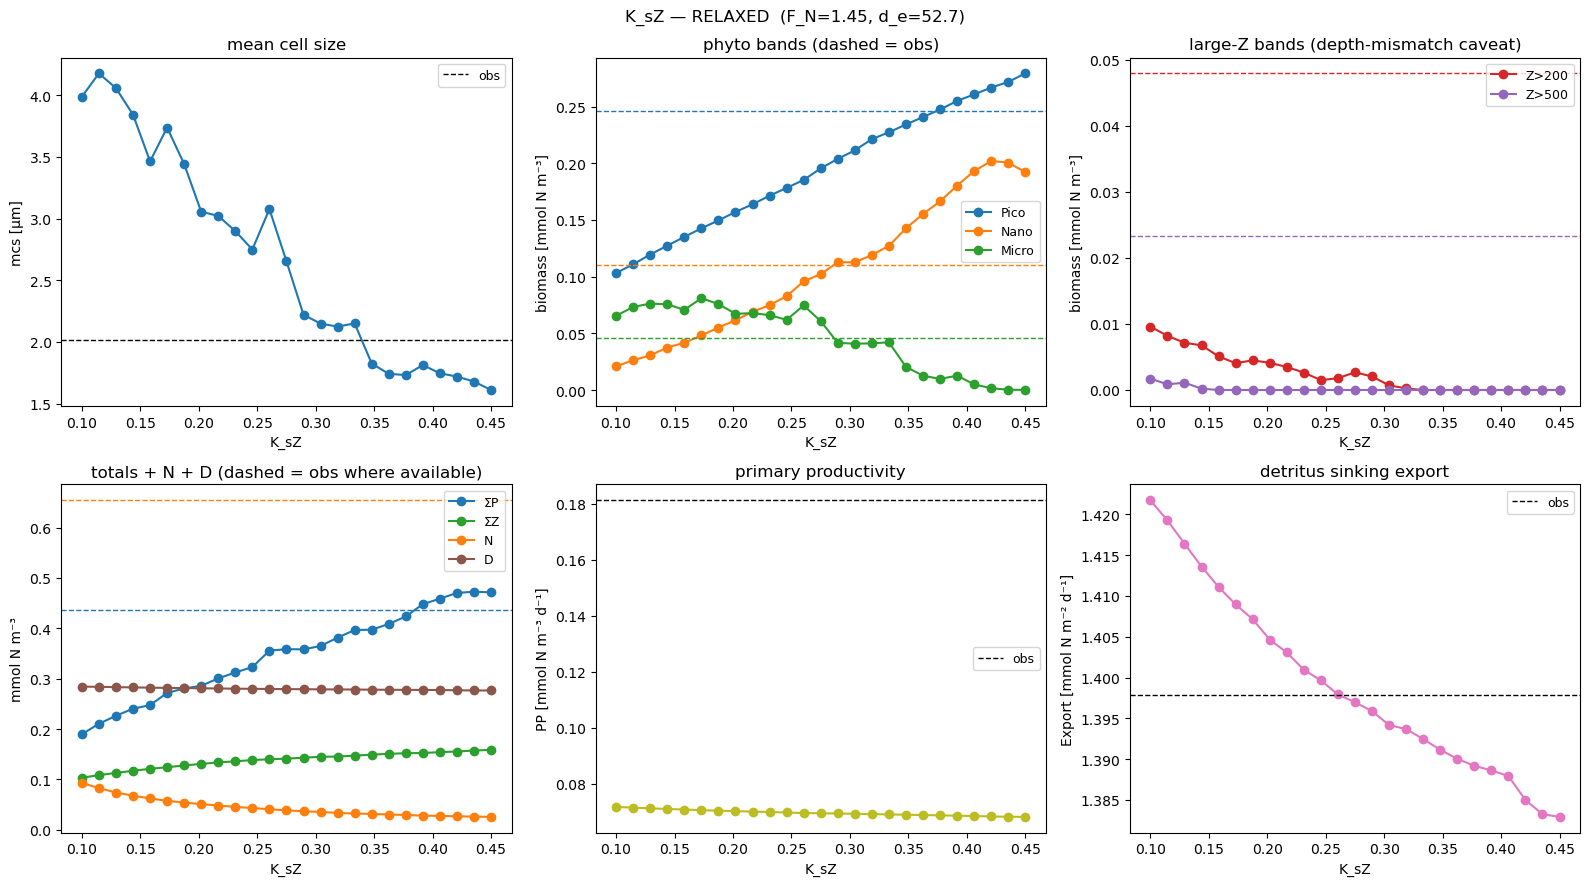

In [28]:
# ── Cell — K_sZ sweep, RELAXED ──────────────────────────────────────────────
PARAM       = 'Grazing__KsZ'
AXIS_LABEL  = 'K_sZ'
AXIS_VALUES = np.linspace(0.10, 0.45, 25)
REGIME      = 'relaxed'
TAIL_AVG    = 1000

obs_refs_rel = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_KsZ_rel = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_KsZ_rel = pue.extract_scan_metrics_1d(
    scan_KsZ_rel, PARAM, targets[REGIME]['forcing'])

header_rel = (f"K_sZ — {REGIME.upper()}  "
              f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_KsZ_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_KsZ_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 50 points using 8 workers...
1D Scan complete. Time taken: 73.37767 seconds.

=== σ — UPWELLING  (F_N=2.58, d_e=42.8) ===
 sigma    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   4.46   0.300   0.142   0.203   0.646  0.0094  0.0000   0.241   0.063   0.491   0.137   2.455
 0.104   4.47   0.294   0.133   0.201   0.628  0.0098  0.0000   0.238   0.065   0.491   0.138   2.457
 0.108   4.33   0.289   0.124   0.191   0.605  0.0104  0.0000   0.235   0.067   0.492   0.138   2.460
 0.112   4.23   0.285   0.119   0.183   0.587  0.0102  0.0000   0.232   0.068   0.493   0.138   2.464
 0.116   4.25   0.281   0.118   0.182   0.580  0.0110  0.0000   0.229

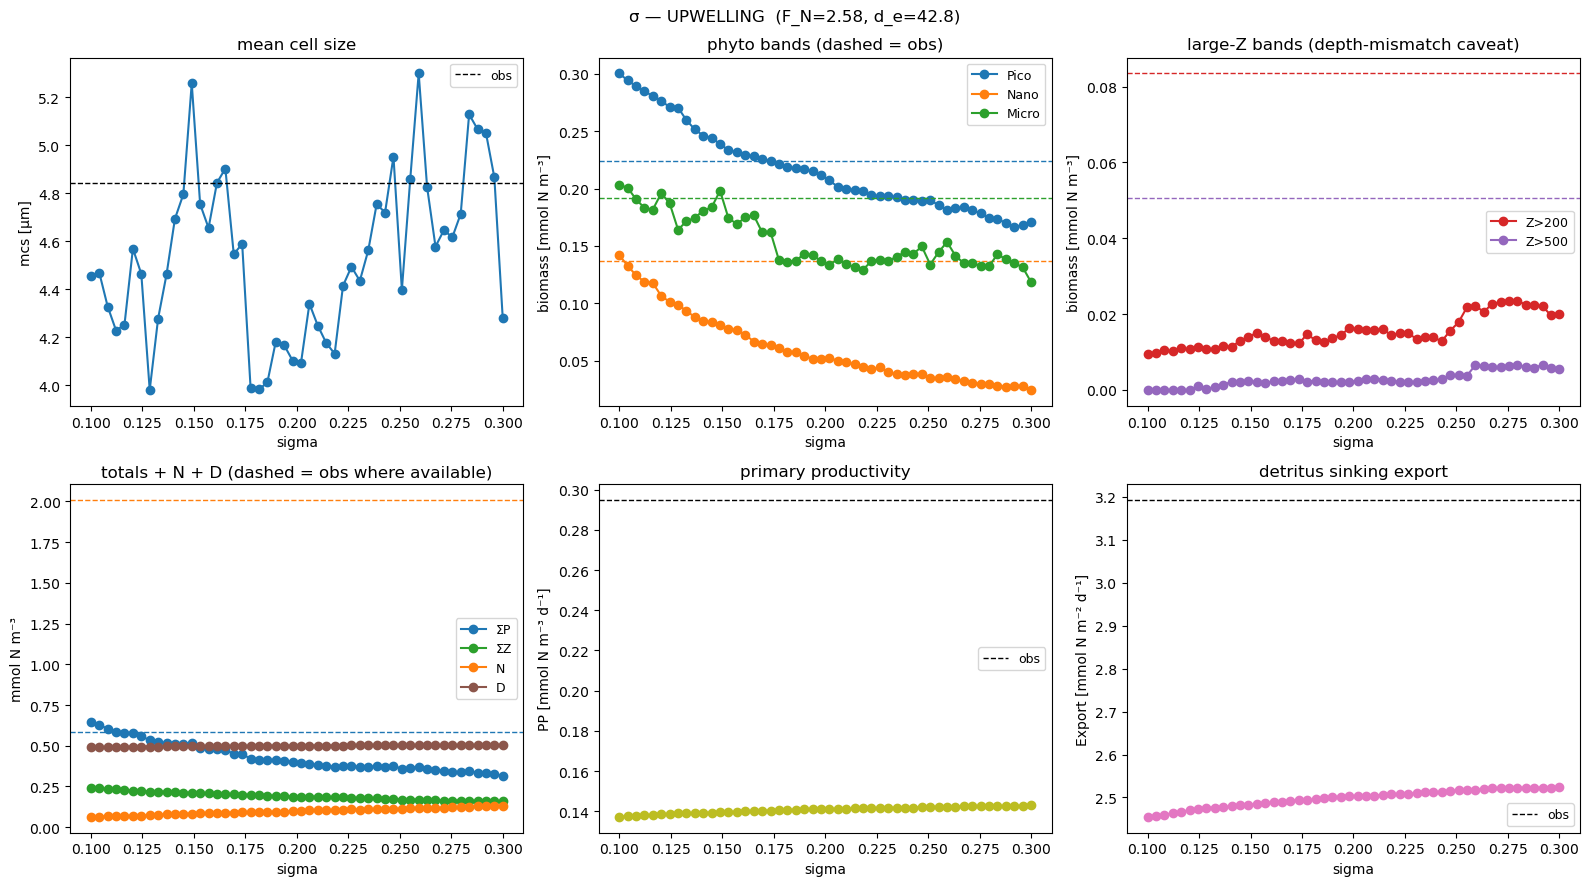

In [32]:
# ── Cell — σ (kernel width) sweep, UPWELLING ────────────────────────────────
# Grazing__sigma_log scan via baseline_r0 (now scannable scalar after refactor).
# Range covers Mattern 2026's tested values: 0.15 default + 0.30 wide-kernel
# SI experiment, extended down to 0.10 for narrower kernels.
PARAM       = 'Grazing__sigma_log'
AXIS_LABEL  = 'sigma'
AXIS_VALUES = np.linspace(0.10, 0.30, 50)   # baseline 0.15 inside
REGIME      = 'upwelling'
TAIL_AVG    = 1000

obs_refs_up = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_sig_up = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_sig_up = pue.extract_scan_metrics_1d(
    scan_sig_up, PARAM, targets[REGIME]['forcing'])

header_up = (f"σ — {REGIME.upper()}  "
             f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
             f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_sig_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_sig_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 21 points using 8 workers...
1D Scan complete. Time taken: 26.26665 seconds.

=== σ — RELAXED  (F_N=1.45, d_e=52.7) ===
 sigma    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.100   2.55   0.223   0.136   0.059   0.418  0.0008  0.0000   0.152   0.034   0.278   0.069   1.390
 0.110   2.50   0.212   0.119   0.056   0.388  0.0010  0.0000   0.148   0.036   0.278   0.069   1.393
 0.120   2.54   0.202   0.105   0.058   0.365  0.0011  0.0000   0.144   0.038   0.279   0.069   1.395
 0.130   2.46   0.194   0.093   0.054   0.341  0.0015  0.0000   0.139   0.040   0.280   0.070   1.398
 0.140   2.72   0.181   0.082   0.062   0.324  0.0022  0.0000   0.138  

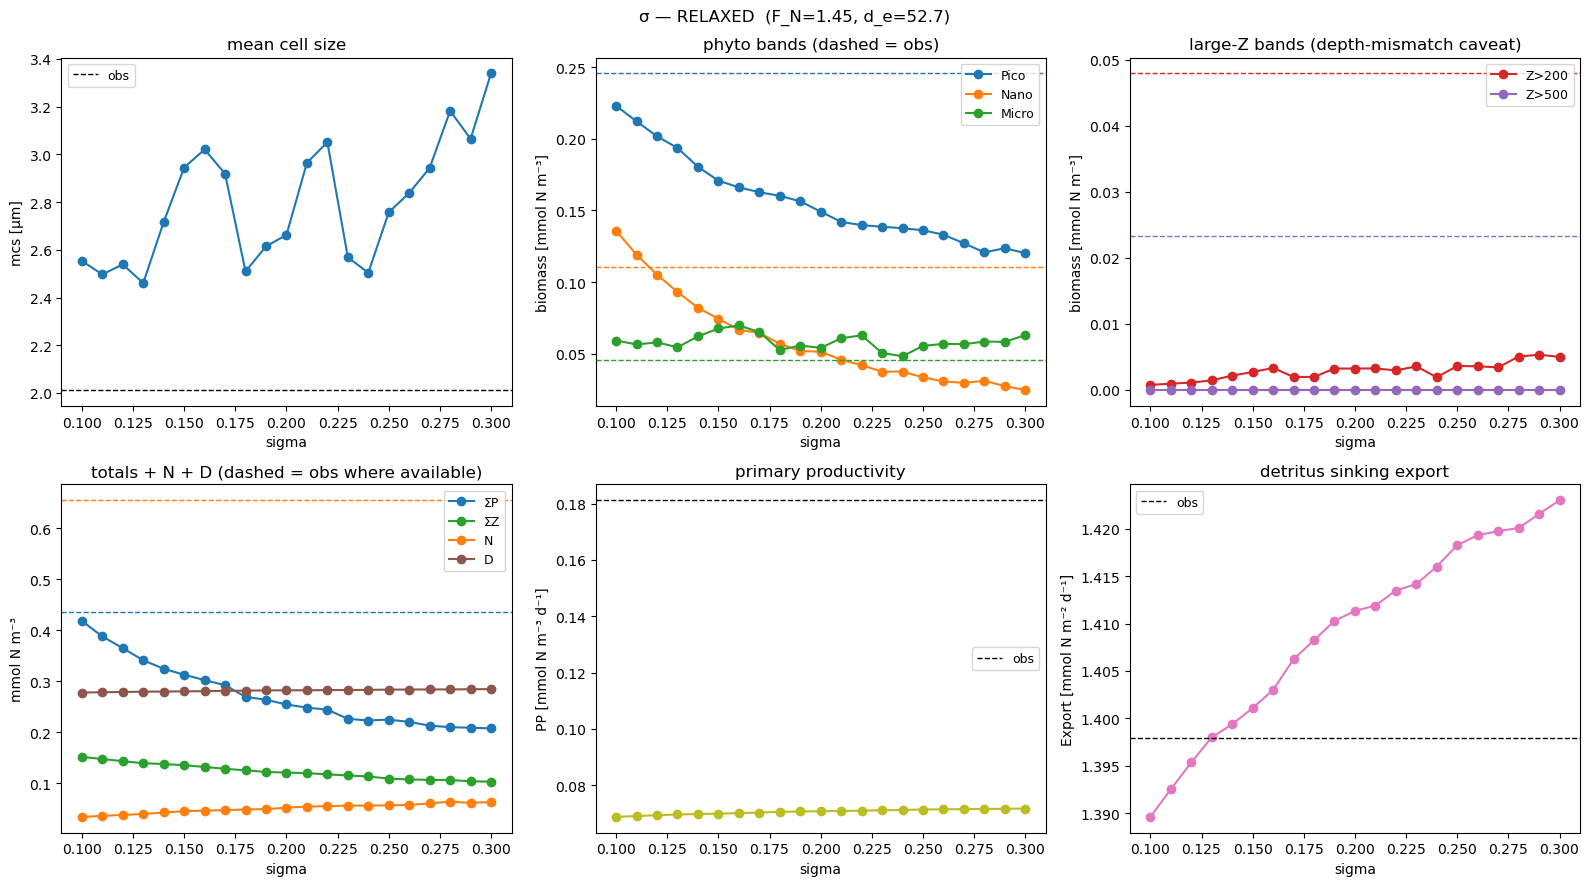

In [30]:
# ── Cell — σ (kernel width) sweep, RELAXED ──────────────────────────────────
PARAM       = 'Grazing__sigma_log'
AXIS_LABEL  = 'sigma'
AXIS_VALUES = np.linspace(0.10, 0.30, 21)
REGIME      = 'relaxed'
TAIL_AVG    = 1000

obs_refs_rel = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_sig_rel = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_sig_rel = pue.extract_scan_metrics_1d(
    scan_sig_rel, PARAM, targets[REGIME]['forcing'])

header_rel = (f"σ — {REGIME.upper()}  "
              f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_sig_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_sig_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
plt.show()

In [31]:
# ── Cell — Mortality combination test (per-class Z quad × Banas phyto) ──────
# Single-point comparison per regime: baseline (bulk quad + uniform m_P=0.02)
# vs combined variant model_baseline_perclassZ_banas (per-class quad Z
# m_Z=1.4 from Dutkiewicz 2015a + Banas size-scaled phyto mortality coeff=0.1).
# Both regimes in one cell (no parscan progress, no output-erasure issue).
TAIL = 1000

def _extract_point_metrics(out, d_e, phyto_esd, zoo_esd):
    """Single-point tail-mean metrics dict — mirrors print_scan_table columns."""
    T = out.isel(time=slice(-TAIL, None))
    P = T['Phytoplankton__biomass'].mean('time').values
    Z = T['Zooplankton__biomass'].mean('time').values
    W = pue.compute_sieburth_weights(phyto_esd)        # (3, n_phyto)
    bins = P @ W.T
    frac = bins / max(bins.sum(), 1e-30)
    return dict(
        mcs    = float(10.0 ** (frac @ np.log10(pue.CARIACO_PHYTO_BIN_GEOMEANS))),
        P_pico = float(bins[0]), P_nano = float(bins[1]), P_micro = float(bins[2]),
        sumP   = float(P.sum()),
        Z_gt200= float(Z[zoo_esd > 200.0].sum()),
        Z_gt500= float(Z[zoo_esd > 500.0].sum()),
        sumZ   = float(Z.sum()),
        N      = float(T['Nutrient__value'].mean('time')),
        D      = float(T['Detritus__value'].mean('time')),
        PP     = float(T['Growth__uptake_value'].mean('time').sum()),
        Export = float(T['DetritusSink__sinking_value'].mean('time')) * d_e,
    )

f3 = lambda v: f"{v:7.3f}" if np.isfinite(v) else f"{'-':>7}"
f4 = lambda v: f"{v:7.4f}" if np.isfinite(v) else f"{'-':>7}"
fm = lambda v: f"{v:6.2f}" if np.isfinite(v) else f"{'-':>6}"

def _row(label, m):
    return (f"{label:>10} {fm(m['mcs'])} {f3(m['P_pico'])} {f3(m['P_nano'])} "
            f"{f3(m['P_micro'])} {f3(m['sumP'])} {f4(m['Z_gt200'])} "
            f"{f4(m['Z_gt500'])} {f3(m['sumZ'])} {f3(m['N'])} {f3(m['D'])} "
            f"{f3(m['PP'])} {f3(m['Export'])}")

for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    obs = pue.build_obs_refs(targets[r]['monthly_df'])

    # Run both model variants at the same regime forcing
    out_base = pu.run_single_point(brs.model_baseline,
                                    brs.setup_baseline,
                                    scan_params={},
                                    fixed_overrides=targets[r]['forcing'])
    out_comb = pu.run_single_point(brs.model_baseline_perclassZ_banas,
                                    brs.setup_baseline_perclassZ_banas,
                                    scan_params={},
                                    fixed_overrides=targets[r]['forcing'])

    m_base = _extract_point_metrics(out_base, d_e, brs.phyto_esd, brs.zoo_esd)
    m_comb = _extract_point_metrics(out_comb, d_e, brs.phyto_esd, brs.zoo_esd)

    o_metrics = dict(
        mcs=obs['mcs'], P_pico=obs['P_pico'], P_nano=obs['P_nano'],
        P_micro=obs['P_micro'], sumP=obs['sumP'],
        Z_gt200=obs['Z_gt200'], Z_gt500=obs['Z_gt500'],
        sumZ=np.nan, N=obs['N'], D=np.nan, PP=obs['PP'], Export=obs['Export'],
    )

    print(f"\n=== Mortality combination test — {r.upper()}  "
          f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={d_e:.1f}) ===")
    print(f"{'config':>10} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7} {'PP':>7} {'Exp':>7}")
    print(_row('baseline',  m_base))
    print(_row('+combo',    m_comb))
    print(_row('obs',       o_metrics))


=== Mortality combination test — UPWELLING  (F_N=2.58, d_e=42.8) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
  baseline   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
    +combo   0.78   0.210   0.021   0.000   0.231  0.0000  0.0000   0.181   0.101   0.501   0.136   2.503
       obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192

=== Mortality combination test — RELAXED  (F_N=1.45, d_e=52.7) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
  baseline   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
    +combo   0.63   0.143   0.000   0.000   0.143  0.0000  0.0000   0.108   0.058   0.281   0.067   1.406
       obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398


--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_perclassZ' and setup 'setup_baseline_perclassZ_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 21 points using 8 workers...
1D Scan complete. Time taken: 31.26297 seconds.

=== m_Z per-class — UPWELLING  (F_N=2.58, d_e=42.8) ===
m_Z_pc    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.050   3.11   0.242   0.046   0.118   0.406  0.0204  0.0027   0.242   0.088   0.515   0.143   2.575
 0.122   3.15   0.242   0.047   0.119   0.409  0.0198  0.0028   0.241   0.088   0.514   0.143   2.569
 0.195   3.14   0.243   0.048   0.119   0.410  0.0186  0.0027   0.239   0.087   0.513   0.143   2.564
 0.267   3.15   0.243   0.048   0.119   0.410  0.0176  0.0026   0.238   0.087   0.512   0.143   2.559
 0.340   3.16   0.243   0.049   0.119

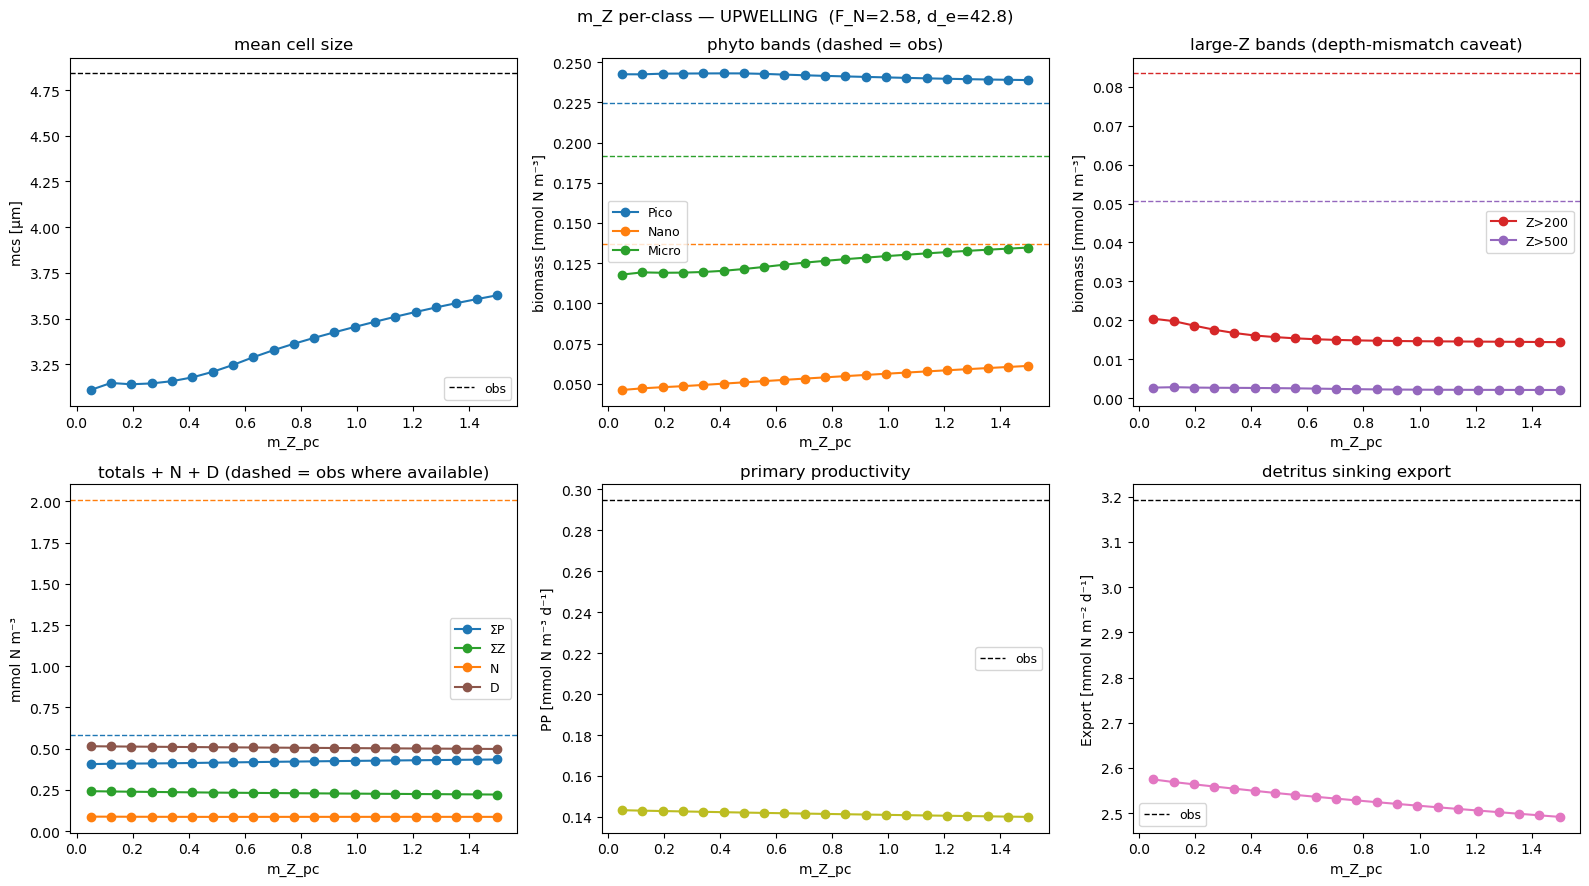

In [33]:
# ── Cell — per-class m_Z sweep (model_baseline_perclassZ), UPWELLING ─────────
# Scan ZooQuadMortality__rate on the per-class variant (uniform m_P=0.02 stays
# the phyto mortality). Range bracketing both the bulk-default value (0.1) and
# the Dutkiewicz 2015a literature value (1.4) — find where the per-class form
# stays viable.
PARAM       = 'ZooQuadMortality__rate'
AXIS_LABEL  = 'm_Z_pc'
AXIS_VALUES = np.linspace(0.05, 1.5, 21)   # default 1.4 sits at the top end
REGIME      = 'upwelling'
TAIL_AVG    = 1000

obs_refs_up = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_mZpc_up = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_perclassZ',
    model_setup_name='setup_baseline_perclassZ_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_mZpc_up = pue.extract_scan_metrics_1d(
    scan_mZpc_up, PARAM, targets[REGIME]['forcing'])

header_up = (f"m_Z per-class — {REGIME.upper()}  "
             f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
             f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_mZpc_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_mZpc_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_perclassZ' and setup 'setup_baseline_perclassZ_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 21 points using 8 workers...
1D Scan complete. Time taken: 25.28437 seconds.

=== m_Z per-class — RELAXED  (F_N=1.45, d_e=52.7) ===
m_Z_pc    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.050   2.26   0.174   0.054   0.050   0.278  0.0035  0.0000   0.151   0.046   0.289   0.072   1.447
 0.323   2.44   0.174   0.057   0.056   0.286  0.0031  0.0000   0.147   0.046   0.287   0.071   1.436
 0.595   2.44   0.174   0.059   0.056   0.289  0.0030  0.0000   0.144   0.046   0.285   0.071   1.426
 0.868   2.50   0.174   0.060   0.057   0.291  0.0030  0.0000   0.142   0.046   0.283   0.071   1.417
 1.140   2.58   0.173   0.062   0.059  

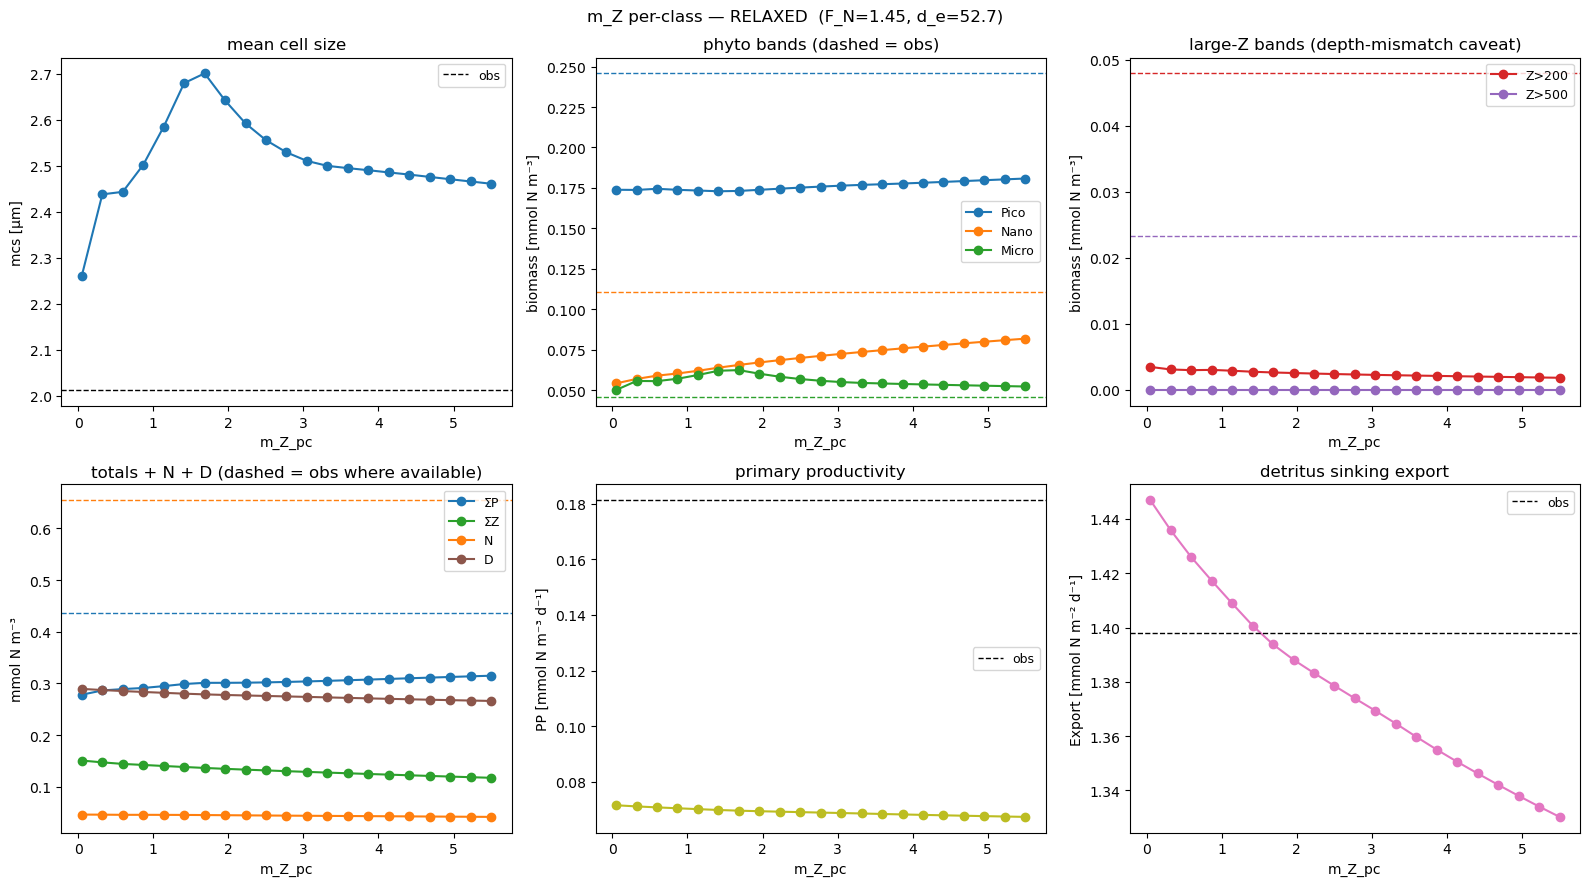

In [41]:
# ── Cell — per-class m_Z sweep (model_baseline_perclassZ), RELAXED ──────────
PARAM       = 'ZooQuadMortality__rate'
AXIS_LABEL  = 'm_Z_pc'
AXIS_VALUES = np.linspace(0.05, 5.5, 21)
REGIME      = 'relaxed'
TAIL_AVG    = 1000

obs_refs_rel = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_mZpc_rel = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_perclassZ',
    model_setup_name='setup_baseline_perclassZ_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_mZpc_rel = pue.extract_scan_metrics_1d(
    scan_mZpc_rel, PARAM, targets[REGIME]['forcing'])

header_rel = (f"m_Z per-class — {REGIME.upper()}  "
              f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_mZpc_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_mZpc_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 20.39615 seconds.

=== Banas coeff — UPWELLING  (F_N=2.58, d_e=42.8) ===
banas_c    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.010   9.21   0.242   0.095   0.356   0.692  0.0263  0.0106   0.220   0.080   0.495   0.140   2.476
 0.020   9.11   0.236   0.089   0.343   0.668  0.0200  0.0042   0.210   0.083   0.497   0.139   2.484
 0.030   5.33   0.230   0.082   0.194   0.505  0.0129  0.0016   0.204   0.087   0.498   0.138   2.490
 0.040   3.11   0.229   0.074   0.104   0.407  0.0065  0.0000   0.199   0.088   0.499   0.138   2.495
 0.050   1.97   0.230   0.072   0.051   0.353 

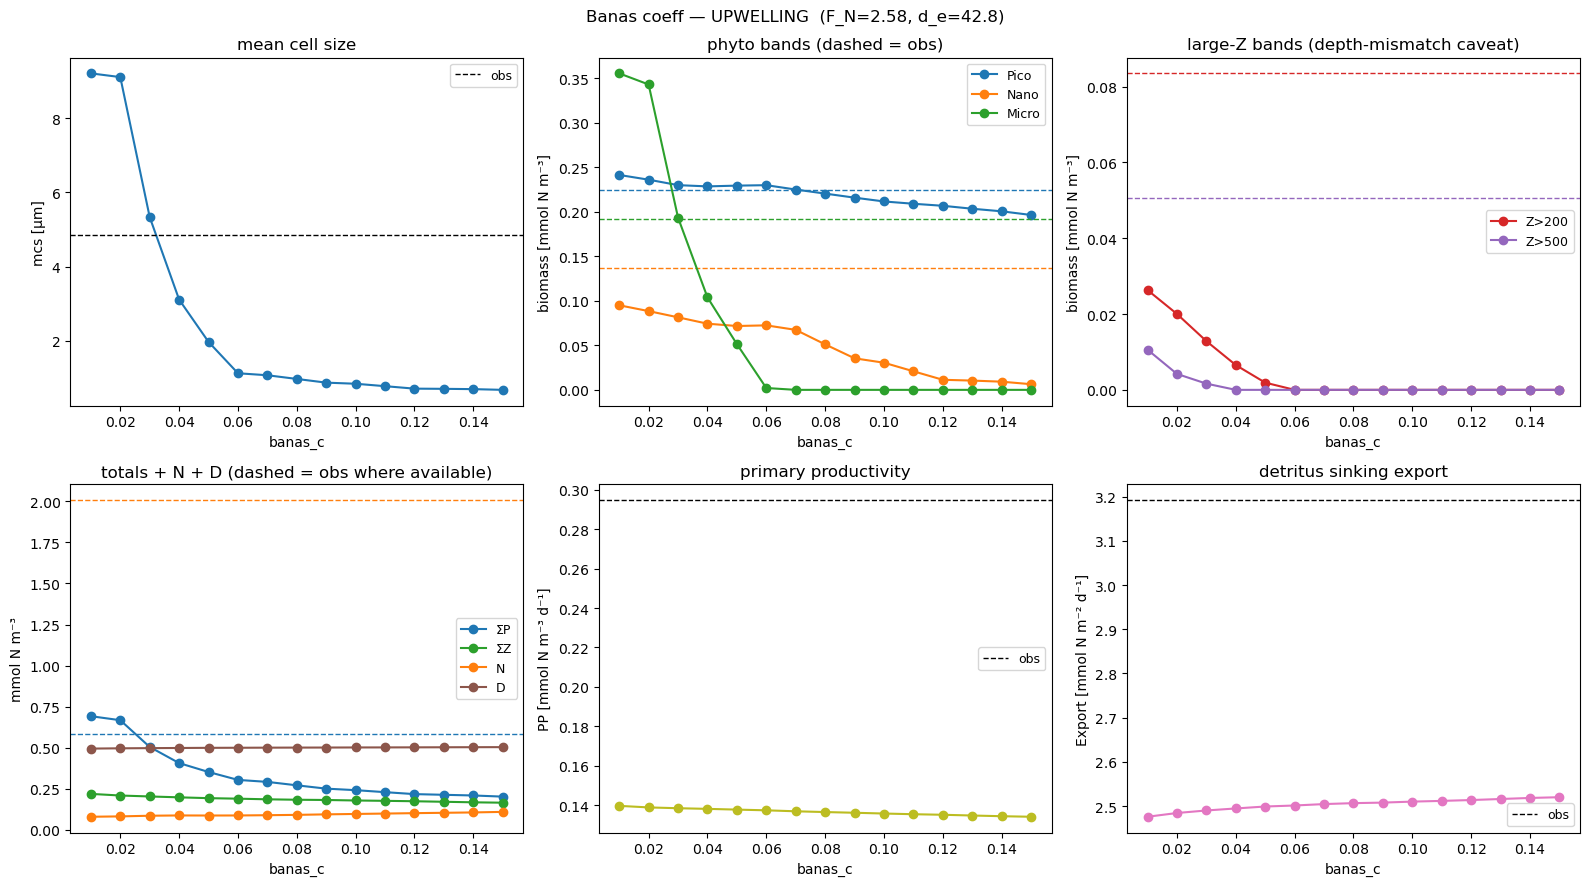

In [39]:
# ── Cell — Banas coeff sweep (model_baseline_banas), UPWELLING ──────────────
# Scan PhytoMortality__coeff on the Banas-phyto-mortality variant (bulk Z quad
# m_Z=0.1 stays). Banas 2011 cites coeff=0.1 = 10% of μ_max as the canonical
# value. Scan around that, low end captures where m_P stays moderate.
PARAM       = 'PhytoMortality__coeff'
AXIS_LABEL  = 'banas_c'
AXIS_VALUES = np.linspace(0.01, 0.15, 15)   # default 0.1 inside
REGIME      = 'upwelling'
TAIL_AVG    = 1000

obs_refs_up = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_banas_up = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_banas_up = pue.extract_scan_metrics_1d(
    scan_banas_up, PARAM, targets[REGIME]['forcing'])

header_up = (f"Banas coeff — {REGIME.upper()}  "
             f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
             f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_banas_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_banas_up, obs_refs_up, header_up, axis_label=AXIS_LABEL)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_banas' and setup 'setup_baseline_banas_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 15 points using 8 workers...
1D Scan complete. Time taken: 17.60594 seconds.

=== Banas coeff — RELAXED  (F_N=1.45, d_e=52.7) ===
banas_c    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.010  10.75   0.178   0.088   0.311   0.577  0.0113  0.0031   0.138   0.042   0.280   0.070   1.400
 0.020   5.31   0.168   0.082   0.139   0.388  0.0040  0.0008   0.133   0.045   0.281   0.070   1.404
 0.030   2.93   0.165   0.077   0.064   0.306  0.0012  0.0000   0.128   0.047   0.282   0.069   1.408
 0.040   1.42   0.164   0.078   0.004   0.246  0.0000  0.0000   0.124   0.047   0.282   0.069   1.410
 0.050   1.16   0.160   0.058   0.000   0.218  0

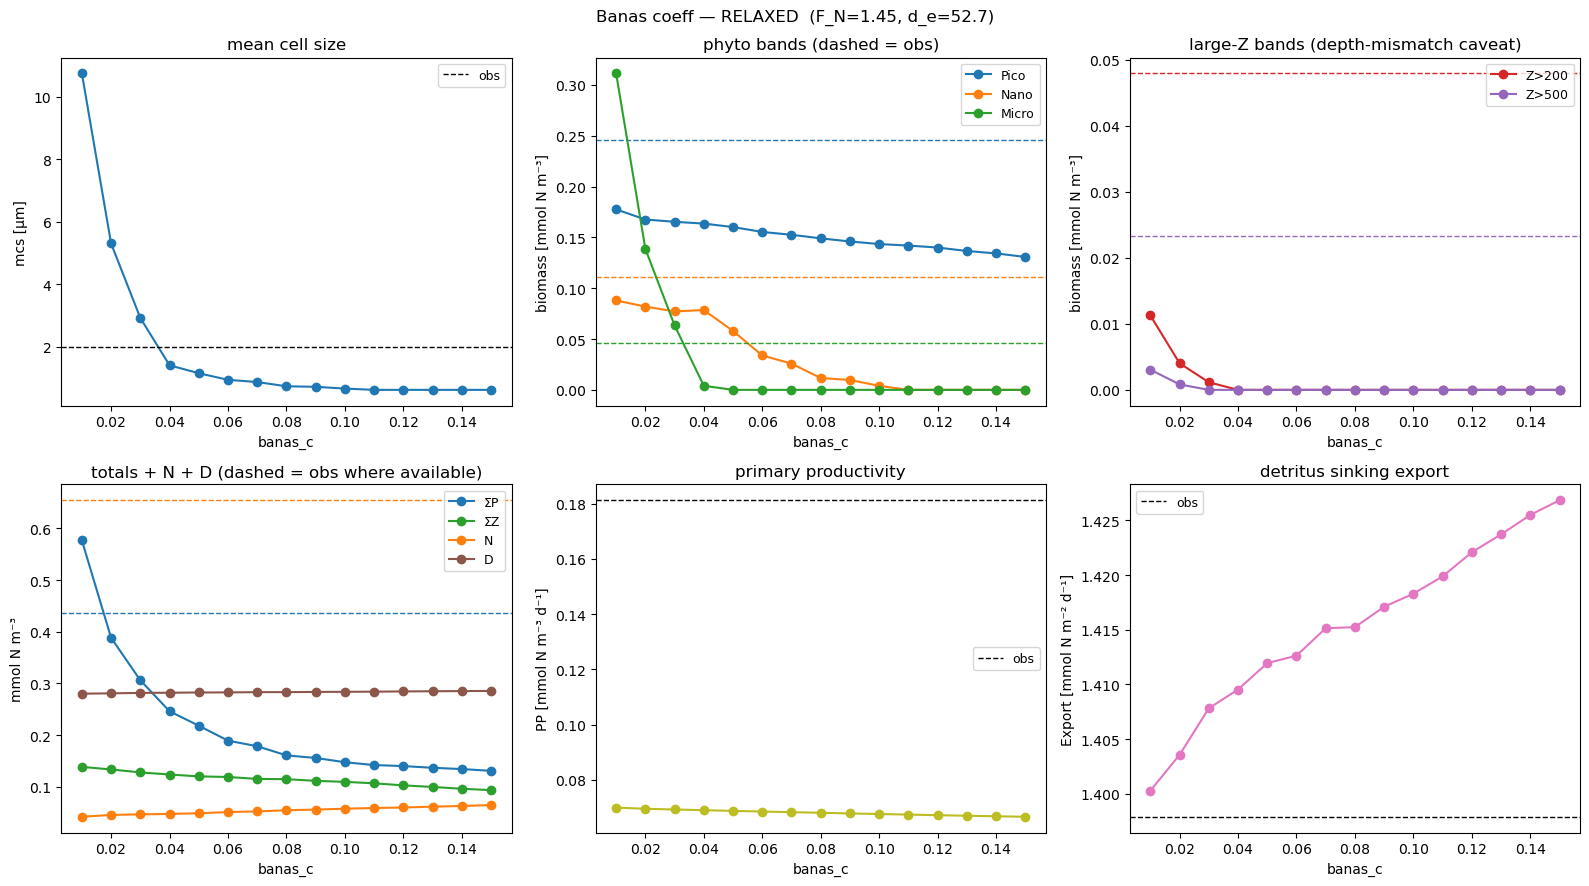

In [40]:
# ── Cell — Banas coeff sweep (model_baseline_banas), RELAXED ────────────────
PARAM       = 'PhytoMortality__coeff'
AXIS_LABEL  = 'banas_c'
AXIS_VALUES = np.linspace(0.01, 0.15, 15)
REGIME      = 'relaxed'
TAIL_AVG    = 1000

obs_refs_rel = pue.build_obs_refs(targets[REGIME]['monthly_df'])

scan_banas_rel = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline_banas',
    model_setup_name='setup_baseline_banas_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=targets[REGIME]['forcing'],
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_banas_rel = pue.extract_scan_metrics_1d(
    scan_banas_rel, PARAM, targets[REGIME]['forcing'])

header_rel = (f"Banas coeff — {REGIME.upper()}  "
              f"(F_N={targets[REGIME]['forcing']['Inflow__FN']:.2f}, "
              f"d_e={targets[REGIME]['forcing']['Inflow__de']:.1f})")
pue.print_scan_table_1d(metrics_banas_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_banas_rel, obs_refs_rel, header_rel, axis_label=AXIS_LABEL)
plt.show()

In [43]:
# ── Cell — NIGHT SCAN SMOKE TEST (small grid, single regime) ─────────────────
# Nested 2D parscan (K_sZ × σ inner) + Python loop over outer params.
# Smoke version: 3×3 inner × 4 outer = 36 points, should run in ~30 sec.
# Confirms the pipeline (parscan → extract → flatten → incremental save)
# before committing to the full overnight run.
import itertools, time
import xarray as xr
from xso.parscans import run_xso_parscan

REGIME    = 'upwelling'
SAVE_PATH = 'smoke_scan_upwelling.nc'

# Inner axes — what the 2D parscan sweeps in parallel via XSO workers
INNER_AXES = {
    'Grazing__KsZ':        np.array([0.15, 0.25, 0.35]),
    'Grazing__sigma_log':  np.array([0.12, 0.18, 0.25]),
}
# Outer axes — Python loop combinations (small for smoke)
OUTER_AXES = {
    'GrazingRouter__gge':      np.array([0.25, 0.35]),
    'DetritusRemin__k_remin':  np.array([0.10, 0.20]),
}

inner_names = list(INNER_AXES.keys())
outer_names = list(OUTER_AXES.keys())

regime_forcing = targets[REGIME]['forcing']
obs_refs       = pue.build_obs_refs(targets[REGIME]['monthly_df'])

n_inner  = int(np.prod([len(v) for v in INNER_AXES.values()]))
n_outer  = int(np.prod([len(v) for v in OUTER_AXES.values()]))
n_total  = n_inner * n_outer
print(f"Smoke test — {n_inner} inner × {n_outer} outer = {n_total} points")

METRIC_KEYS = ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
               'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']

t0 = time.time()
results = []   # list of flat dicts, one per outer combo
for i, outer_combo in enumerate(itertools.product(*OUTER_AXES.values())):
    outer_overrides = dict(zip(outer_names, outer_combo))
    full_overrides  = {**regime_forcing, **outer_overrides}

    scan = run_xso_parscan(
        model_file_name='baseline_r0_setups',
        model_name='model_baseline',
        model_setup_name='setup_baseline_slim',
        param_name=inner_names[0],
        param_values=INNER_AXES[inner_names[0]],
        param_name2=inner_names[1],
        param_values2=INNER_AXES[inner_names[1]],
        fixed_overrides=full_overrides,
        postprocess_name='avg_tail',
        postprocess_kwargs={'avg_window': 1000},
        processes=8,
    )

    metrics = pue.extract_scan_metrics_2d(
        scan, inner_names[0], inner_names[1], regime_forcing)

    # Flatten the 2D inner grid into long-form rows
    n1, n2 = len(metrics['axis_1']), len(metrics['axis_2'])
    n_pts  = n1 * n2
    A1, A2 = np.meshgrid(metrics['axis_1'], metrics['axis_2'], indexing='ij')
    flat = {
        inner_names[0]: A1.ravel(),
        inner_names[1]: A2.ravel(),
    }
    for name, value in outer_overrides.items():
        flat[name] = np.full(n_pts, value)
    for k in METRIC_KEYS:
        flat[k] = metrics[k].ravel()
    results.append(flat)

    # Incremental save after each outer iteration
    combined = {key: np.concatenate([r[key] for r in results])
                for key in flat}
    n_samples = len(next(iter(combined.values())))
    ds = xr.Dataset({k: (('sample',), v) for k, v in combined.items()},
                    coords={'sample': np.arange(n_samples)})
    ds.to_netcdf(SAVE_PATH)
    print(f"  outer {i+1}/{n_outer}: {outer_overrides} → {n_pts} pts, "
          f"total saved: {n_samples}")

elapsed = time.time() - t0
print(f"\nDone. Total: {n_samples} samples. Time: {elapsed:.1f} sec "
      f"(per-point avg: {elapsed/n_samples*1000:.0f} ms)")
print(f"Saved to: {SAVE_PATH}")

# Sanity check: load back, compute err, peek at best fit
ds_check = xr.open_dataset(SAVE_PATH)
metrics_loaded = {k: ds_check[k].values for k in METRIC_KEYS}
err_eq = pue.joint_error(metrics_loaded, obs_refs)
err_zw = pue.joint_error(metrics_loaded, obs_refs,
                          weights={**{t: 1.0 for t in pue.DEFAULT_TARGETS},
                                   'Z_gt200': 2.0, 'Z_gt500': 2.0})
ds_check['err_eq'] = (('sample',), err_eq)
ds_check['err_zw'] = (('sample',), err_zw)
ds_check.to_netcdf(SAVE_PATH)   # re-save with err columns
i_best_eq = int(np.nanargmin(err_eq))
print(f"\nBest equal-weighted fit (idx {i_best_eq}, err_eq={err_eq[i_best_eq]:.3f}):")
for k in list(INNER_AXES.keys()) + list(OUTER_AXES.keys()):
    print(f"  {k:30s} = {float(ds_check[k][i_best_eq]):.3f}")
for k in METRIC_KEYS:
    print(f"  {k:30s} = {float(ds_check[k][i_best_eq]):.4f}")

PROGRESS: Completed 3/3 outer points. (Grazing__KsZ = 0.15).

2D Scan complete. Total Time taken: 32.32465 seconds.
  outer 4/4: {'GrazingRouter__gge': np.float64(0.35), 'DetritusRemin__k_remin': np.float64(0.2)} → 9 pts, total saved: 36

Done. Total: 36 samples. Time: 114.6 sec (per-point avg: 3183 ms)
Saved to: smoke_scan_upwelling.nc

Best equal-weighted fit (idx 27, err_eq=0.466):
  Grazing__KsZ                   = 0.350
  Grazing__sigma_log             = 0.250
  GrazingRouter__gge             = 0.250
  DetritusRemin__k_remin         = 0.100
  mcs                            = 4.6368
  P_pico                         = 0.2246
  P_nano                         = 0.0251
  P_micro                        = 0.1689
  sumP                           = 0.4186
  Z_gt200                        = 0.0598
  Z_gt500                        = 0.0134
  sumZ                           = 0.3179
  N                              = 0.1735
  D                              = 0.4726
  PP                        

In [44]:
# ── Cell — NIGHT SCAN: nested 2D parscan, both regimes (Option A) ────────────
# Inner (XSO parscan): K_sZ × σ at 10 × 10 = 100 points
# Outer (Python loop):  GGE × k_remin × w_sink × m_Z at 4 × 4 × 3 × 3 = 144
# Total per regime: 14,400 samples; estimated ~2 hr per regime → ~4 hr total
# Saves to night_scan_{regime}.nc; err_eq + err_zw added after each regime
import itertools, time
from xso.parscans import run_xso_parscan

SAVE_PATH_FMT = 'night_scan_{regime}.nc'

# Inner axes — XSO parallelises across these in each parscan call
INNER_AXES = {
    'Grazing__KsZ':        np.linspace(0.10, 0.45, 10),
    'Grazing__sigma_log':  np.linspace(0.10, 0.30, 10),
}
# Outer axes — Python loop combinations
OUTER_AXES = {
    'GrazingRouter__gge':      np.linspace(0.20, 0.40, 4),
    'DetritusRemin__k_remin':  np.linspace(0.05, 0.30, 4),
    'DetritusSink__w_sink':    np.linspace(2.5, 15.0, 3),
    'ZooQuadMortality__rate':  np.linspace(0.05, 0.30, 3),
}

inner_names = list(INNER_AXES.keys())
outer_names = list(OUTER_AXES.keys())

n_inner = int(np.prod([len(v) for v in INNER_AXES.values()]))
n_outer = int(np.prod([len(v) for v in OUTER_AXES.values()]))
print(f"NIGHT SCAN — {n_inner} inner × {n_outer} outer = "
      f"{n_inner * n_outer:,} samples / regime")
print(f"Both regimes back-to-back; incremental save after each outer iteration\n")

METRIC_KEYS = ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
               'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']

ZW_WEIGHTS = {**{t: 1.0 for t in pue.DEFAULT_TARGETS},
              'Z_gt200': 2.0, 'Z_gt500': 2.0}

for REGIME in ['upwelling', 'relaxed']:
    print(f"\n{'=' * 66}\nStarting {REGIME.upper()}\n{'=' * 66}")
    regime_forcing = targets[REGIME]['forcing']
    obs_refs       = pue.build_obs_refs(targets[REGIME]['monthly_df'])
    save_path      = SAVE_PATH_FMT.format(regime=REGIME)

    t0      = time.time()
    results = []

    for i, outer_combo in enumerate(itertools.product(*OUTER_AXES.values())):
        outer_overrides = dict(zip(outer_names, outer_combo))
        full_overrides  = {**regime_forcing, **outer_overrides}

        scan = run_xso_parscan(
            model_file_name='baseline_r0_setups',
            model_name='model_baseline',
            model_setup_name='setup_baseline_slim',
            param_name=inner_names[0],
            param_values=INNER_AXES[inner_names[0]],
            param_name2=inner_names[1],
            param_values2=INNER_AXES[inner_names[1]],
            fixed_overrides=full_overrides,
            postprocess_name='avg_tail',
            postprocess_kwargs={'avg_window': 1000},
            processes=8,
        )

        metrics = pue.extract_scan_metrics_2d(
            scan, inner_names[0], inner_names[1], regime_forcing)

        # Flatten 2D inner grid to long-form rows
        n1, n2 = len(metrics['axis_1']), len(metrics['axis_2'])
        n_pts  = n1 * n2
        A1, A2 = np.meshgrid(metrics['axis_1'], metrics['axis_2'], indexing='ij')
        flat = {inner_names[0]: A1.ravel(), inner_names[1]: A2.ravel()}
        for name, value in outer_overrides.items():
            flat[name] = np.full(n_pts, value)
        for k in METRIC_KEYS:
            flat[k] = metrics[k].ravel()
        results.append(flat)

        # Incremental save (crash-safety: lose at most one outer iteration)
        combined = {key: np.concatenate([r[key] for r in results])
                    for key in flat}
        n_samples = len(next(iter(combined.values())))
        ds = xr.Dataset({k: (('sample',), v) for k, v in combined.items()},
                        coords={'sample': np.arange(n_samples)})
        ds.to_netcdf(save_path)

        # Concise progress every 20 outer iterations (and on the last)
        if (i + 1) % 20 == 0 or (i + 1) == n_outer:
            elapsed = time.time() - t0
            eta_sec = elapsed / (i + 1) * (n_outer - i - 1)
            print(f"  {i+1:3d}/{n_outer} outer  |  "
                  f"{n_samples:6,} samples  |  "
                  f"elapsed {elapsed/60:5.1f} min  |  "
                  f"ETA {eta_sec/60:5.1f} min")

    # ── Add err_eq + err_zw to the regime's netCDF; report best fits ────────
    ds_final = xr.open_dataset(save_path)
    metrics_loaded = {k: ds_final[k].values for k in METRIC_KEYS}
    err_eq = pue.joint_error(metrics_loaded, obs_refs)
    err_zw = pue.joint_error(metrics_loaded, obs_refs, weights=ZW_WEIGHTS)
    ds_final['err_eq'] = (('sample',), err_eq)
    ds_final['err_zw'] = (('sample',), err_zw)
    ds_final.to_netcdf(save_path)

    elapsed_reg = time.time() - t0
    print(f"\n--- {REGIME.upper()} DONE ---")
    print(f"  total: {n_samples:,} samples in {elapsed_reg/60:.1f} min "
          f"({elapsed_reg / n_samples * 1000:.0f} ms/point average)")

    for label, err in [('err_eq', err_eq), ('err_zw', err_zw)]:
        i_best = int(np.nanargmin(err))
        print(f"\n  best {label}: idx {i_best}, value {err[i_best]:.3f}")
        for k in inner_names + outer_names:
            print(f"    {k:30s} = {float(ds_final[k][i_best]):.3f}")
        for k in METRIC_KEYS:
            print(f"    {k:30s} = {float(ds_final[k][i_best]):.4f}")

print("\n\nAll done! Two netCDF files saved.")

PROGRESS: Completed 10/10 outer points. (Grazing__KsZ = 0.45).

2D Scan complete. Total Time taken: 200.79713 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 2D parallel scan of 'baseline_r0_setups' (Grazing__KsZ x Grazing__sigma_log).
Outer loop (10 points) running in parallel with 8 workers.
Inner loop (10 points) running sequentially per worker.
Total points: 100.


Process SpawnPoolWorker-691:
Process SpawnPoolWorker-690:
Process SpawnPoolWorker-692:
Process SpawnPoolWorker-695:
Process SpawnPoolWorker-693:
Process SpawnPoolWorker-697:
Process SpawnPoolWorker-696:
Process SpawnPoolWorker-694:


KeyboardInterrupt: 